# Task: 
## 1. Crawl the text reviews of Nangman BBQ restaurant on the provided website
## 2. Cluster the crawled restaurants into 3 groups based on their reviews 
## 3. Identify the characteristics of each sorted groups 

# Skills: Web Scraping, Data Preprocessing, Data Clustering, Data Visualization, Data Interpretation

### 1. Crawl all the text reviews of the Nangman BBQ restaurant on Opentable.com:

In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import time

In [3]:
driver = webdriver.Chrome()

In [5]:
all_reviews = []
for page in range(1, 17):
    url = f"https://www.opentable.com/r/nangman-bbq-new-york?page={page}"
    driver.get(url)
    time.sleep(3)

    reviews = driver.find_elements(By.CLASS_NAME, "_6rFG6U7PA6M-")
    for el in reviews:
        all_reviews.append(el.text)

In [7]:
all_reviews

['This was my second visit, and it was just as outstanding as the first. The BBQ was flavorful, tender, and grilled to perfection. What stood out even more this time was the variety of Korean side dishes that came with the meal — each one was fresh, well-prepared, and complemented the meat beautifully. The service was warm and attentive, striking just the right balance without being overbearing. You can tell that every detail, from the food to the hospitality, is handled with care. I’ll definitely be returning — it’s the kind of place you find yourself craving again and again.\nRead more',
 'Truly a hidden gem!\n\nThe meats were perfectly grilled, the side dishes were fresh and tasty, and the service was warm and thoughtful. One of the highlights was that they grill the meat for you right at the table—it made everything so relaxing and enjoyable. The atmosphere was cozy and welcoming—just the kind of place you want to keep coming back to.\n\nHighly recommend. I truly hope this place ge

### 2. Convert the text reviews to a bag-of-words using TF-IDF scores; Convert upper case letters to lower case, delete stopwords, and lemmatize the words

In [10]:
from nltk.tokenize import word_tokenize

In [12]:
from nltk.corpus import stopwords

In [14]:
nltk_stopwords= set(stopwords.words("english"))
nltk_stopwords

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [18]:
from nltk.stem import WordNetLemmatizer
lem = WordNetLemmatizer()

In [20]:
def my_tokenizer(r):
    r1 = word_tokenize(r) #convert into vector? tokenize it
    r2 = [w.lower() for w in r1 if w.isalpha()] #convert the upper into lowercase
    r3 = [w for w in r2 if not w in nltk_stopwords] #remove stopwords
    r4 = [lem.lemmatize(w) for w in r3]
    return r4

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
tfidf = TfidfVectorizer(tokenizer = my_tokenizer, token_pattern = None)

In [26]:
tfidf_review = tfidf.fit_transform(all_reviews)
tfidf_review

<160x1041 sparse matrix of type '<class 'numpy.float64'>'
	with 3194 stored elements in Compressed Sparse Row format>

In [27]:
tfidf_review.toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.24533373,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [30]:
len(tfidf_review.toarray())

160

In [32]:
tfidf_terms = tfidf.get_feature_names_out()
tfidf_terms

array(['able', 'abroad', 'absolutely', ..., 'yummy', 'è', '떡갈비'],
      dtype=object)

In [34]:
len(tfidf_review.toarray())

160

In [36]:
import pandas as pd

In [38]:
review_bow = pd.DataFrame(tfidf_review.toarray(), columns = tfidf_terms)

In [40]:
review_bow

,able,abroad,absolutely,accommodating,accompaniment,accompanying,acknowledged,acknowledgement,across,actual,...,worth,would,wrap,wrapped,write,yes,young,yummy,è,떡갈비
0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
1,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
2,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.139706,0.0,0.0,0.205556,0.0,0.0,0.0,0.000000,0.0
3,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
4,0.216287,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.073500,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,0.000000,0.0,0.0,0.150618,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.102368,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
156,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.123546,0.0,0.0,...,0.0,0.073166,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
157,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
158,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.245334,0.0


### 3. Choose the “optimal” number of clusters using the elbow method, and apply K-means clustering on the text reviews

In [43]:
from sklearn.cluster import KMeans

In [45]:
km = KMeans(n_clusters=3, random_state = 0) 

In [47]:
km_model = km.fit(tfidf_review)

In [49]:
clusters = km_model.labels_.tolist()
clusters

[2,
 2,
 2,
 0,
 0,
 2,
 1,
 0,
 1,
 2,
 2,
 2,
 1,
 0,
 2,
 2,
 2,
 0,
 2,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 1,
 2,
 0,
 2,
 0,
 0,
 0,
 1,
 0,
 1,
 2,
 2,
 1,
 0,
 2,
 0,
 2,
 2,
 2,
 2,
 2,
 0,
 2,
 2,
 2,
 0,
 2,
 2,
 1,
 2,
 1,
 0,
 2,
 2,
 1,
 2,
 2,
 1,
 2,
 2,
 2,
 1,
 2,
 1,
 2,
 0,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 0,
 1,
 1,
 1,
 2,
 0,
 2,
 2,
 2,
 2,
 2,
 1,
 0,
 2,
 0,
 0,
 2,
 2,
 2,
 0,
 1,
 0,
 0,
 2,
 0,
 2,
 0,
 2,
 1,
 2,
 2,
 2,
 1,
 2,
 2,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 2,
 2,
 1,
 1,
 2,
 2,
 1,
 1,
 2,
 2,
 0,
 1,
 2,
 0,
 2,
 2,
 2,
 0,
 2,
 1,
 2,
 2,
 1,
 0,
 2,
 2,
 2,
 2,
 1,
 1]

In [51]:
len(clusters)

160

In [53]:
km_model.inertia_

147.01995386561313

In [55]:
Ks=list(range(1,6))
Ks

[1, 2, 3, 4, 5]

In [57]:
distance =[]

for k in Ks:
    km_n= KMeans(n_clusters=k, random_state=0)
    km_model_n=km_n.fit(tfidf_review)
    d = km_model_n.inertia_
    distance.append(d)

#the first loop the sum of each documents 

In [59]:
distance

[151.24414503250733,
 149.23313473821037,
 147.01995386561313,
 145.52688671440796,
 144.31784461636414]

In [61]:
from matplotlib import pyplot as plt

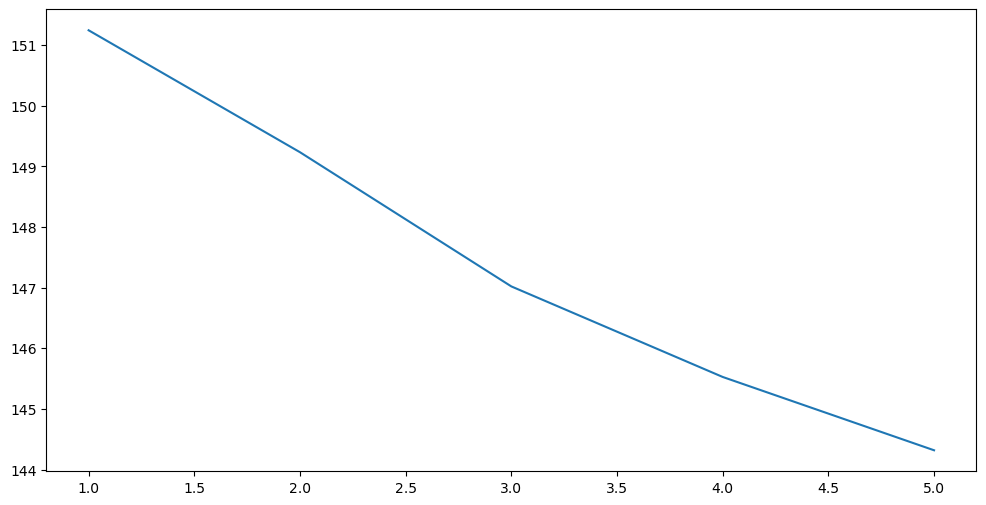

In [62]:
plt.figure(figsize=(12,6))
plt.plot(Ks, distance)
plt.show()

### 4.Create a table that shows text reviews and the cluster number that each text review belongs to, as shown below:

In [66]:
import pandas as pd

In [68]:
table= pd.DataFrame({"Review": all_reviews, "Cluster": clusters})
table

,Review,Cluster
0,"This was my second visit, and it was just as o...",2
1,Truly a hidden gem!\n\nThe meats were perfectl...,2
2,Best BBQ experience of my entire life. I never...,2
3,Food mediocre to poor. Service nice but slow...,0
4,I came here for a birthday dinner on a Wednesd...,0
...,...,...
155,Nangman has a very cute outdoor set up (indoor...,2
156,"A disappointing experience, in every sense. We...",2
157,We had an outstanding dinner here! Came on a w...,2
158,Veramente un posto interessante da visitare co...,1


#5. See if you can characterize each cluster using the most common/relevant words for each cluster;

In [71]:
km_model.cluster_centers_

array([[0.00636139, 0.        , 0.01108098, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.00618465, 0.03060498, ..., 0.        , 0.00663064,
        0.        ],
       [0.00478961, 0.        , 0.00609616, ..., 0.00242348, 0.        ,
        0.00114818]])

In [73]:
cent = km_model.cluster_centers_.argsort()[:, ::-1]
cent

array([[ 799,  388,  350, ...,  533,  531, 1040],
       [ 297,  291,  350, ...,  642,  641,    0],
       [ 394,  350,   78, ...,  485,  141,  395]])

In [75]:
tfidf_terms[7]

'acknowledgement'

In [77]:
for i in range(0,3):
    top_words = [tfidf_terms[x] for x in cent[i, :5]]
    print(top_words)

['service', 'good', 'food', 'great', 'quality']
['excellent', 'everything', 'food', 'service', 'delicious']
['great', 'food', 'bbq', 'experience', 'korean']


# 1. Reviews in cluster 0 highlight the overall satisfaction with the restaurant
# 2. Reviews in cluster 1 highlight the good food and service
# 3. Reviews in cluster 2 highlight specific dishes such as bbq korean